## Defining CLASS and loading files!

In [1]:
import numpy as np
import pandas as pd
import pickle
from mpi4py import MPI
import os
import sys
from tqdm import tqdm
from collections import defaultdict
import dill
sys.path.append('/mn/stornext/u3/hassanif/neutrino_niayesh/Analysis/nu_code/library_snapshot')
import sys
import os
sys.path.append('/mn/stornext/u3/hassanif/neutrino_niayesh/Analysis/nu_code/')
# from library_snapshot import bulk_velocity # For the x-y analysis
from bulk_velocity_pylians import bulk_calculation_pylians
import readsnap
# from analysis_functions import perform_analysis
# from analysis_functions import load_halo_data
from analysis_functions import *
# from computation_xy import *
from Cross_spectra_computation_pylians import cross_power_spectra_pylians
import MAS_library as MASL
import Pk_library as PKL
import matplotlib.pyplot as plt

In [193]:
# boxsize = 1024
# bulk_species1 ="cdm"
# bulk_species2 ="cdm"
# mass_limit =1e12
# save_path ="./output"
# file_path ="/mn/stornext/u3/hassanif/neutrino_niayesh/Analysis/Run_Bulk_velocities_CIC//"
# ngrid_min =89
# ngrid_max =90
# ngrid_step =1

# sim_type ="0.3ev"
# spec ="L_1024_Ngrid_2600"

In [17]:
ngrid = 89
# data = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_1024/0.3ev/cdm/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_1024_cdm.pickle")
# data2 = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_1024/0.3ev/halo_mass_2e13/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_1024_halo_mass_2.0e+13.pickle")

data = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_2048/0.3ev/nu/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_2048_nu.pickle")
data2 = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_2048/0.3ev///cdm/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_2048_cdm.pickle")


In [18]:

density_tmp = data['sub_box_data']['density']
# density2 = data2['sub_box_data']['density']
min_density = 1e-25  # Small positive value
density_tmp2 = np.where(density_tmp <= 0, min_density, density_tmp)
# density2 = np.where(density2 <= 0, min_density, density2)
delta_org = density_tmp2 / np.mean(density_tmp2, dtype=np.float64) - 1.0
# delta2 = density2 / np.mean(density2, dtype=np.float64) - 1.0

Vx = data['sub_box_data']['P_x']
Vy = data['sub_box_data']['P_y']
Vz = data['sub_box_data']['P_z']
# Normalize velocity by density
Vx = np.where(delta_org > min_density, Vx / delta_org, 0)
Vy = np.where(delta_org > min_density, Vy / delta_org, 0)
Vz = np.where(delta_org > min_density, Vz / delta_org, 0)

### field2 velocity fields
# Vx2 = data2['sub_box_data']['P_x']
# Vy2 = data2['sub_box_data']['P_y']
# Vz2 = data2['sub_box_data']['P_z']
# # Normalize velocity by density
# Vx2 = np.where(density2 > min_density, Vx2 / density2, 0)
# Vy2 = np.where(density2 > min_density, Vy2 / density2, 0)
# Vz2 = np.where(density2 > min_density, Vz2 / density2, 0)

axis     = 0       #no RSD
MAS      = 'CIC'   #it assumes the density constrast and velocities have been generated with the same MAS
threads  = 1       #number of openmp threads
verbose = False 
boxsize = 1024

# Let's compute the auto spectra and cross

In [23]:
# k, Pk_11, Pk_22, Pk_12, Nmodes = PKL.XPk_vv(delta1, Vx1, Vy1, Vz1, delta2, Vx2, Vy2, Vz2, BoxSize, axis, MAS, threads)
# k_12, Pk_11, Pk_22, Pk_12, Nmodes = PKL.XPk_vv(delta, Vx, Vy, Vz, delta2, Vx2, Vy2, Vz2, boxsize, axis, MAS, threads)

k, Pk_dd0, Pk_tt0, Pk_dt0, Nmodes = PKL.XPk_dv(delta_org*100, Vx, Vy, Vz, boxsize, axis, MAS, threads)
# k, Pk_dd0_2, Pk_tt0_2, Pk_dt0_2, Nmodes = PKL.XPk_dv(delta*1000, Vx, Vy, Vz, boxsize, axis, MAS, threads)

k, Pk_theta, Nmodes = PKL.Pk_theta(Vx,Vy,Vz, boxsize,axis,MAS,threads)
# k2, Pk2, Nmodes = PKL.Pk_theta(Vx2,Vy2,Vz2, boxsize,axis,MAS,threads)

Computing power spectra of the fields...
Time compute modulus = 0.03
Time taken = 0.19 seconds
Computing power spectrum of theta...
Time compute modulus = 0.02
Time taken = 0.15 seconds


In [24]:
Pk_tt0/Pk_theta

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1.])

# Loading CLASS

In [21]:

def nested_dict(n, type):
    if n==1:
        defaultdict(type)
    else:
        return defaultdict(lambda: nested_dict(n-1, type))

data_class = nested_dict(6, list);


redshifts_class = [1000, 100, 50, 30,20, 10, 9, 8, 7, 6 , 5, 4, 3, 2.5, 2, 1.5, 1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.001, 0.0001, 0]

sims = ["0.0ev", "0.15ev", "0.3ev", "0.6ev", "0.9ev"]
for z in redshifts_class:
    for sim in sims:
        z_index = redshifts_class.index(z)
        # print(sim[:-2])
        data_class['tk']['class'][sim][z] = np.loadtxt("./../../runs_class/Runs_class_all/output_"+str(sim[:-2])+"/z"+str(z_index+1)+"_tk.dat")



# PLotting them

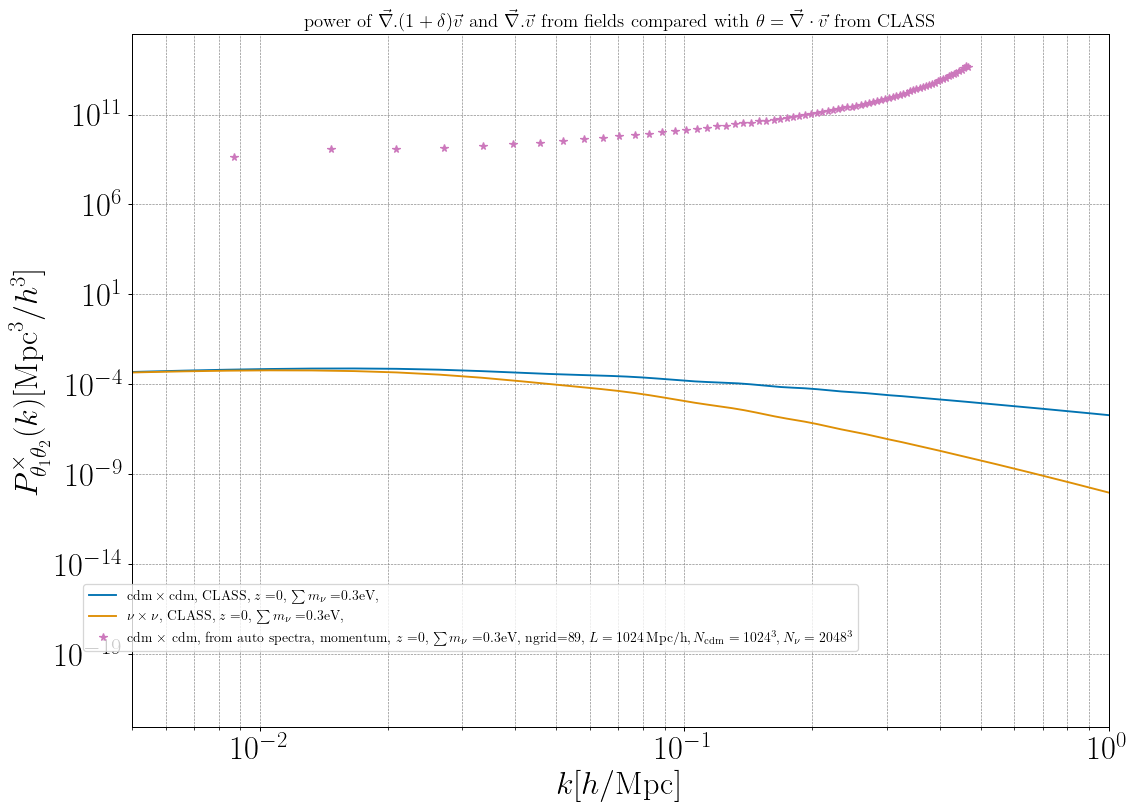

In [25]:
from matplotlib.lines import Line2D
import seaborn as sns

Colors = sns.color_palette("colorblind", 12).as_hex()
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': 26}
plt.rc('font', **font)

markersize = 7; alpha_num = 1;


# specs = ["L_1024_Ngrid_2048", "L_1024_Ngrid_2048_Ngrid_4096" ]
specs = ["L_1024_Ngrid_1024" ]

# nhs = [3, 4, 6, 8]
sims_all = ["0.0ev"]
boxsize = 1024.;
# Loop through each combination of spec, num_halos, Mass_cut, and sim
config_sim_print = [r'$L = 1024 {\rm \, Mpc/h}, N_{\rm cdm} = 1024^3, N_{\nu} = 2048^3$']

line_s  = ["o", "*"]
num_ls = 0

h = 0.67
n_s = 0.9619;
k_p = 0.05/h;
h = 0.67
A_s = 2.215e-9

alpha_num = 1
l=0
field2 =r"$\nu$"
field1 =r"${\rm cdm}$"
for spec in specs[:1]:
    num_ls = specs.index(spec);
    for z in [0]:
        l=0
        fig, (ax1) = plt.subplots(1, 1, figsize=(14, 10), dpi=90, sharex=True)
        plt.subplots_adjust(hspace=0.05)
        for sim in sims[2:3]:
        

            data_c = data_class['tk']['class'][sim][z]
            tk_cdm = data_c[:,13]
            tk_nu = data_c[:,14]
            k_c = data_c[:,0]
            normalization =  A_s * (k_c/k_p)**(n_s-1.) * (2.* np.pi**2)/k_c**3    
            p_nuxnu_class = tk_nu* tk_nu * normalization/h**2
            p_cdmxcdm_class = tk_cdm* tk_cdm * normalization/h**2
            ax1.plot(k_c, p_cdmxcdm_class, "-", color= Colors[l], label=r"${\rm cdm} \times {\rm cdm}$"+r", CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")

            ax1.plot(k_c, p_nuxnu_class, "-", color= Colors[l+1], label=rf"$\nu \times \nu$"+r", CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")

            c_light = 299792.458 # km/s 
            coeff = 1./c_light**2
            # k_12, Pk_11, Pk_22, Pk_12
            # ax1.plot(k_12, Pk_11 * coeff, "o", color= Colors[l], label=rf"{field1} $\times$ {field1}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            # ax1.plot(k_12, Pk_22 * coeff, "o", color= Colors[l+1], label=rf"{field2} $\times$ {field2}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            # ax1.plot(k_12, Pk_12 * coeff, "s", color= Colors[l+3],label=rf"{field1} $\times$ {field2}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            # ax1.plot(k, k, Pk_theta * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            ax1.plot(k, Pk_theta * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            # ax1.plot(k, Pk_tt0 * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            # ax1.plot(k_2, Pk_tt0_2 * coeff, "*", color= Colors[l+5], label=rf"{field2} $\times$ {field2}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            ax1.set_xlabel(r'$k [h/{\rm Mpc}]$ ')
            ax1.set_ylabel(r'$P^{\times}_{\theta_1 \theta_2}(k) [{\rm Mpc}^3/h^3]$')
            # ax1.legend()
            # ax1.set_title(r"$M_h \ge \,$" + Mass_cut[5:6]+ r" $\times 10^{" + Mass_cut[10:] + r" } \, M_{\odot}$, " +", $n_h=$"+str(num_halos), fontsize=15)
        
            ax1.set_title(r"power of $\vec \nabla . (1+\delta) \vec v$ and $\vec \nabla . \vec v$ from fields compared with $\theta = \vec \nabla \cdot \vec v$ from CLASS", fontsize=15)
            # ax1.set_ylim(1.e-6, 1.e-2)
            ax1.set_xlim((5.e-3, 1))
            ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.grid(True)  # Add grid lines with default settings
            ax1_legend = ax1.legend(loc='lower right', bbox_to_anchor=(0.75, 0.1), frameon=True, fontsize= 11)
            # Optional: Customize grid appearance
            ax1.grid(which='both', color='gray', linestyle='--', linewidth=0.5)  # Customize grid lines
            l=l+1

plt.show()

# Halo

In [188]:
ngrid = 89
# data = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_1024/0.3ev/cdm/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_1024_cdm.pickle")
# data2 = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_1024/0.3ev/halo_mass_2e13/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_1024_halo_mass_2.0e+13.pickle")

data = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_2048/0.3ev/halo_mass_1e13/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_2048_halo_mass_1.0e+13.pickle")
data2 = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_2048/0.3ev/nu/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_2048_nu.pickle")


In [189]:

density = data['sub_box_data']['density']
density2 = data2['sub_box_data']['density']
min_density = 1e-25  # Small positive value
density = np.where(density <= 0, min_density, density)
density2 = np.where(density2 <= 0, min_density, density2)
delta = density / np.mean(density, dtype=np.float64) - 1.0
delta2 = density2 / np.mean(density2, dtype=np.float64) - 1.0

Vx = data['sub_box_data']['P_x']
Vy = data['sub_box_data']['P_y']
Vz = data['sub_box_data']['P_z']
# Normalize velocity by density
Vx = np.where(density > min_density, Vx / density, 0)
Vy = np.where(density > min_density, Vy / density, 0)
Vz = np.where(density > min_density, Vz / density, 0)

### field2 velocity fields
Vx2 = data2['sub_box_data']['P_x']
Vy2 = data2['sub_box_data']['P_y']
Vz2 = data2['sub_box_data']['P_z']
# Normalize velocity by density
Vx2 = np.where(density2 > min_density, Vx2 / density2, 0)
Vy2 = np.where(density2 > min_density, Vy2 / density2, 0)
Vz2 = np.where(density2 > min_density, Vz2 / density2, 0)

axis     = 0       #no RSD
MAS      = 'CIC'   #it assumes the density constrast and velocities have been generated with the same MAS
threads  = 1       #number of openmp threads
verbose = False 
boxsize = 1024

In [190]:
# k, Pk_11, Pk_22, Pk_12, Nmodes = PKL.XPk_vv(delta1, Vx1, Vy1, Vz1, delta2, Vx2, Vy2, Vz2, BoxSize, axis, MAS, threads)
k_12, Pk_11, Pk_22, Pk_12, Nmodes = PKL.XPk_vv(delta, Vx, Vy, Vz, delta2, Vx2, Vy2, Vz2, boxsize, axis, MAS, threads)

# k, Pk_dd0, Pk_tt0, Pk_dt0, Nmodes = PKL.XPk_dv(delta, Vx, Vy, Vz, boxsize, axis, MAS, threads)
# k, Pk, Nmodes = PKL.Pk_theta(Vx,Vy,Vz, boxsize,axis,MAS,threads)
# k2, Pk2, Nmodes = PKL.Pk_theta(Vx2,Vy2,Vz2, boxsize,axis,MAS,threads)

Computing power spectra of the fields...
Time compute modulus = 0.03
Time taken = 0.35 seconds


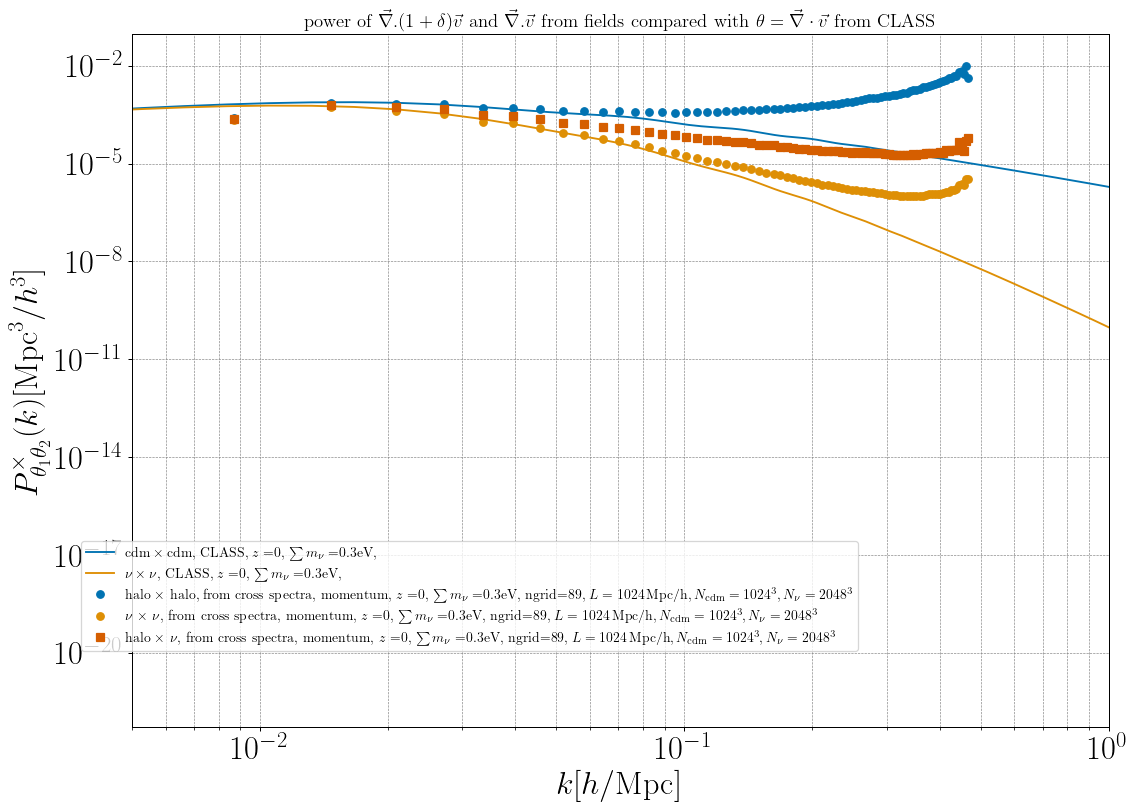

In [191]:
from matplotlib.lines import Line2D
import seaborn as sns

Colors = sns.color_palette("colorblind", 12).as_hex()
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': 26}
plt.rc('font', **font)

markersize = 7; alpha_num = 1;


# specs = ["L_1024_Ngrid_2048", "L_1024_Ngrid_2048_Ngrid_4096" ]
specs = ["L_1024_Ngrid_1024" ]

# nhs = [3, 4, 6, 8]
sims_all = ["0.0ev"]
boxsize = 1024.;
# Loop through each combination of spec, num_halos, Mass_cut, and sim
config_sim_print = [r'$L = 1024 {\rm \, Mpc/h}, N_{\rm cdm} = 1024^3, N_{\nu} = 2048^3$']

line_s  = ["o", "*"]
num_ls = 0

h = 0.67
n_s = 0.9619;
k_p = 0.05/h;
h = 0.67
A_s = 2.215e-9

alpha_num = 1
l=0
field1 =r"{\rm halo}"
field2 =r"$\nu$"
for spec in specs[:1]:
    num_ls = specs.index(spec);
    for z in [0]:
        l=0
        fig, (ax1) = plt.subplots(1, 1, figsize=(14, 10), dpi=90, sharex=True)
        plt.subplots_adjust(hspace=0.05)
        for sim in sims[2:3]:
        

            data_c= data_class['tk']['class'][sim][z]
            tk_cdm = data_c[:,13]
            tk_nu = data_c[:,14]
            k_c = data_c[:,0]
            normalization =  A_s * (k_c/k_p)**(n_s-1.) * (2.* np.pi**2)/k_c**3    
            p_nuxnu_class = tk_nu* tk_nu * normalization/h**2
            p_cdmxcdm_class = tk_cdm* tk_cdm * normalization/h**2
            ax1.plot(k_c, p_cdmxcdm_class, "-", color= Colors[l], label=r"${\rm cdm} \times {\rm cdm}$"+r", CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")

            ax1.plot(k_c, p_nuxnu_class, "-", color= Colors[l+1], label=rf"$\nu \times \nu$"+r", CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")

            c_light = 299792.458 # km/s 
            coeff = 1./c_light**2
            # k_12, Pk_11, Pk_22, Pk_12
            ax1.plot(k_12, Pk_11 * coeff, "o", color= Colors[l], label=rf"{field1} $\times$ {field1}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            ax1.plot(k_12, Pk_22 * coeff, "o", color= Colors[l+1], label=rf"{field2} $\times$ {field2}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            ax1.plot(k_12, Pk_12 * coeff, "s", color= Colors[l+3],label=rf"{field1} $\times$ {field2}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            # ax1.plot(k, Pk * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            # ax1.plot(k, Pk2 * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            # ax1.plot(k, Pk_tt0 * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            # ax1.plot(k_2, Pk_tt0_2 * coeff, "*", color= Colors[l+5], label=rf"{field2} $\times$ {field2}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            ax1.set_xlabel(r'$k [h/{\rm Mpc}]$ ')
            ax1.set_ylabel(r'$P^{\times}_{\theta_1 \theta_2}(k) [{\rm Mpc}^3/h^3]$')
            # ax1.legend()
            # ax1.set_title(r"$M_h \ge \,$" + Mass_cut[5:6]+ r" $\times 10^{" + Mass_cut[10:] + r" } \, M_{\odot}$, " +", $n_h=$"+str(num_halos), fontsize=15)
        
            ax1.set_title(r"power of $\vec \nabla . (1+\delta) \vec v$ and $\vec \nabla . \vec v$ from fields compared with $\theta = \vec \nabla \cdot \vec v$ from CLASS", fontsize=15)
            # ax1.set_ylim(1.e-6, 1.e-2)
            ax1.set_xlim((5.e-3, 1))
            ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.grid(True)  # Add grid lines with default settings
            ax1_legend = ax1.legend(loc='lower right', bbox_to_anchor=(0.75, 0.1), frameon=True, fontsize= 11)
            # Optional: Customize grid appearance
            ax1.grid(which='both', color='gray', linestyle='--', linewidth=0.5)  # Customize grid lines
            l=l+1

plt.show()

# CDM - Halo

In [159]:
ngrid = 89
# data = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_1024/0.3ev/cdm/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_1024_cdm.pickle")
# data2 = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_1024/0.3ev/halo_mass_2e13/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_1024_halo_mass_2.0e+13.pickle")

data = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_2048/0.3ev/cdm/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_2048_cdm.pickle")
data2 = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_2048/0.3ev/halo_mass_1e13/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_2048_halo_mass_1.0e+13.pickle")


In [160]:

density = data['sub_box_data']['density']
density2 = data2['sub_box_data']['density']
min_density = 1e-25  # Small positive value
density = np.where(density <= 0, min_density, density)
density2 = np.where(density <= 0, min_density, density)
delta = density / np.mean(density, dtype=np.float64) - 1.0
delta2 = density2 / np.mean(density2, dtype=np.float64) - 1.0

Vx = data['sub_box_data']['P_x']
Vy = data['sub_box_data']['P_y']
Vz = data['sub_box_data']['P_z']
# Normalize velocity by density
Vx = np.where(density > min_density, Vx / density, 0)
Vy = np.where(density > min_density, Vy / density, 0)
Vz = np.where(density > min_density, Vz / density, 0)

### field2 velocity fields
Vx2 = data2['sub_box_data']['P_x']
Vy2 = data2['sub_box_data']['P_y']
Vz2 = data2['sub_box_data']['P_z']
# Normalize velocity by density
Vx2 = np.where(density2 > min_density, Vx2 / density2, 0)
Vy2 = np.where(density2 > min_density, Vy2 / density2, 0)
Vz2 = np.where(density2 > min_density, Vz2 / density2, 0)

axis     = 0       #no RSD
MAS      = 'CIC'   #it assumes the density constrast and velocities have been generated with the same MAS
threads  = 1       #number of openmp threads
verbose = False 
boxsize = 1024

In [161]:
# k, Pk_11, Pk_22, Pk_12, Nmodes = PKL.XPk_vv(delta1, Vx1, Vy1, Vz1, delta2, Vx2, Vy2, Vz2, BoxSize, axis, MAS, threads)
k_12, Pk_11, Pk_22, Pk_12, Nmodes = PKL.XPk_vv(delta, Vx, Vy, Vz, delta2, Vx2, Vy2, Vz2, boxsize, axis, MAS, threads)

# k, Pk_dd0, Pk_tt0, Pk_dt0, Nmodes = PKL.XPk_dv(delta, Vx, Vy, Vz, boxsize, axis, MAS, threads)
# k, Pk, Nmodes = PKL.Pk_theta(Vx,Vy,Vz, boxsize,axis,MAS,threads)
# k2, Pk2, Nmodes = PKL.Pk_theta(Vx2,Vy2,Vz2, boxsize,axis,MAS,threads)

Computing power spectra of the fields...
Time compute modulus = 0.03
Time taken = 0.36 seconds


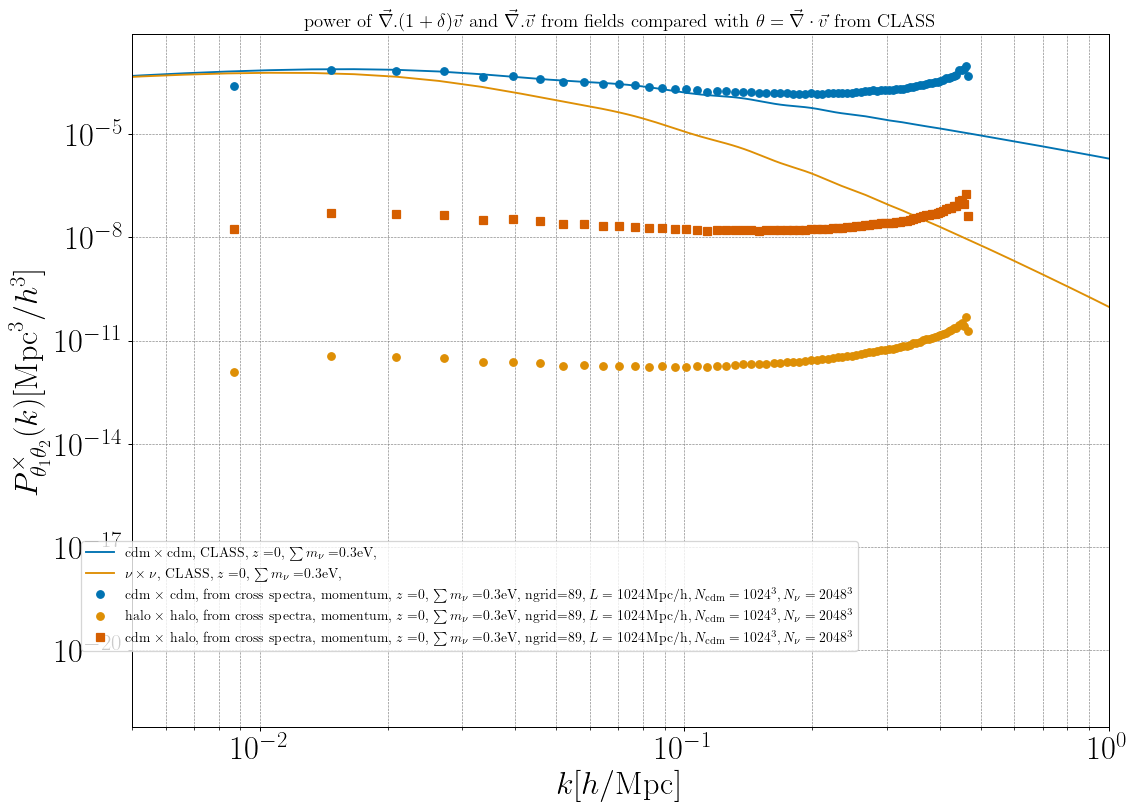

In [163]:
from matplotlib.lines import Line2D
import seaborn as sns

Colors = sns.color_palette("colorblind", 12).as_hex()
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': 26}
plt.rc('font', **font)

markersize = 7; alpha_num = 1;


# specs = ["L_1024_Ngrid_2048", "L_1024_Ngrid_2048_Ngrid_4096" ]
specs = ["L_1024_Ngrid_1024" ]

# nhs = [3, 4, 6, 8]
sims_all = ["0.0ev"]
boxsize = 1024.;
# Loop through each combination of spec, num_halos, Mass_cut, and sim
config_sim_print = [r'$L = 1024 {\rm \, Mpc/h}, N_{\rm cdm} = 1024^3, N_{\nu} = 2048^3$']

line_s  = ["o", "*"]
num_ls = 0

h = 0.67
n_s = 0.9619;
k_p = 0.05/h;
h = 0.67
A_s = 2.215e-9

alpha_num = 1
l=0
field1 =r"{\rm cdm}"
field2 =r"${\rm halo}$"
for spec in specs[:1]:
    num_ls = specs.index(spec);
    for z in [0]:
        l=0
        fig, (ax1) = plt.subplots(1, 1, figsize=(14, 10), dpi=90, sharex=True)
        plt.subplots_adjust(hspace=0.05)
        for sim in sims[2:3]:
        

            data_c= data_class['tk']['class'][sim][z]
            tk_cdm = data_c[:,13]
            tk_nu = data_c[:,14]
            k_c = data_c[:,0]
            normalization =  A_s * (k_c/k_p)**(n_s-1.) * (2.* np.pi**2)/k_c**3    
            p_nuxnu_class = tk_nu* tk_nu * normalization/h**2
            p_cdmxcdm_class = tk_cdm* tk_cdm * normalization/h**2
            ax1.plot(k_c, p_cdmxcdm_class, "-", color= Colors[l], label=r"${\rm cdm} \times {\rm cdm}$"+r", CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")

            ax1.plot(k_c, p_nuxnu_class, "-", color= Colors[l+1], label=rf"$\nu \times \nu$"+r", CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")

            c_light = 299792.458 # km/s 
            coeff = 1./c_light**2
            # k_12, Pk_11, Pk_22, Pk_12
            ax1.plot(k_12, Pk_11 * coeff, "o", color= Colors[l], label=rf"{field1} $\times$ {field1}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            ax1.plot(k_12, Pk_22 * coeff, "o", color= Colors[l+1], label=rf"{field2} $\times$ {field2}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            ax1.plot(k_12, Pk_12 * coeff, "s", color= Colors[l+3],label=rf"{field1} $\times$ {field2}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            # ax1.plot(k, Pk * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            # ax1.plot(k, Pk2 * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            # ax1.plot(k, Pk_tt0 * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            # ax1.plot(k_2, Pk_tt0_2 * coeff, "*", color= Colors[l+5], label=rf"{field2} $\times$ {field2}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            ax1.set_xlabel(r'$k [h/{\rm Mpc}]$ ')
            ax1.set_ylabel(r'$P^{\times}_{\theta_1 \theta_2}(k) [{\rm Mpc}^3/h^3]$')
            # ax1.legend()
            # ax1.set_title(r"$M_h \ge \,$" + Mass_cut[5:6]+ r" $\times 10^{" + Mass_cut[10:] + r" } \, M_{\odot}$, " +", $n_h=$"+str(num_halos), fontsize=15)
        
            ax1.set_title(r"power of $\vec \nabla . (1+\delta) \vec v$ and $\vec \nabla . \vec v$ from fields compared with $\theta = \vec \nabla \cdot \vec v$ from CLASS", fontsize=15)
            # ax1.set_ylim(1.e-6, 1.e-2)
            ax1.set_xlim((5.e-3, 1))
            ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.grid(True)  # Add grid lines with default settings
            ax1_legend = ax1.legend(loc='lower right', bbox_to_anchor=(0.75, 0.1), frameon=True, fontsize= 11)
            # Optional: Customize grid appearance
            ax1.grid(which='both', color='gray', linestyle='--', linewidth=0.5)  # Customize grid lines
            l=l+1

plt.show()